**Distribuciones muestrales**

Objetivo: En esta práctica, aprederemos a diferenciar entre una población y una muestra. También aprenderemos el Teorema del límite central.

Definición. Una **muestra aleatoria simple** es una colección finita de variables aleatorias $X_1, X_2, \ldots, X_n$ independientes e idénticamente distribuidas, provenientes de una población infinita.

Para ejemplificar el concepto de muestra, descargaremos los precios de los activos de apple (por día) del año 2025. Para esto, usaremos el paquete "yfinance" de Python.

Una vez que descarguemos los precios de los activos (clasificados como de apertura, máximo, mínimo y de cierre), calcularemos su rendimiento diario, que se interpreta como el porcentaje de crecimiento del precio de una acción de la empresa con respecto al día anterior.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
apple = yf.download("AAPL", start="2025-01-01", end="2025-12-31")

/tmp/ipykernel_8502/2690166810.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download("AAPL", start="2025-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


Los precios de los activos de apple descargados, desde el 1 de enero de 2025 hasta el 31 de diciembre de 2025, son una muestra de la población de precios históricos de los activos de apple. Sin embargo, en este ejercicio, consideraremos estos datos descargados como "nuestra" población.

In [3]:
print(apple.head())

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-01-02  242.301926  247.518596  240.284814  247.349662  55740700
2025-01-03  241.815033  242.629819  240.354364  241.815033  40244100
2025-01-06  243.444611  245.759820  241.656035  242.758989  45045600
2025-01-07  240.672348  243.991141  239.817807  241.437449  40856000
2025-01-08  241.159210  242.162808  238.526040  240.384163  37628900


Grafiquemos los precios de cierre de los activos de apple descargados:

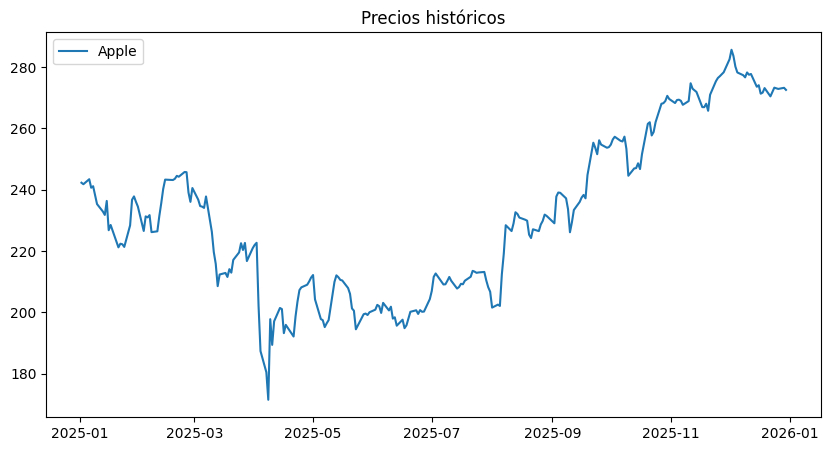

In [4]:
plt.figure(figsize=(10,5))
plt.plot(apple["Close"], label="Apple")
plt.legend()
plt.title("Precios históricos")
plt.show()

Calculemos el rendimiento diario, **R_t**, de Apple, usando la siguiente fórmula:

$$R_t = \frac{P_t-P_{t-1}}{P_{t-1}}$$

Con el método **pct_change()** de Python calcularemos el rendimiento diario:

In [5]:
apple_returns = apple["Close"].pct_change()

Con los rendimientos diarios (de cierre) de apple, estamos construyendo "otra" población de datos.

In [6]:
apple_returns.head()

Ticker,AAPL
Date,
2025-01-02,NaN
2025-01-03,-0.002009
2025-01-06,0.006739
2025-01-07,-0.011388
2025-01-08,0.002023


Como se observa en la salida de apple_returns, hay datos no definidos (Nan). Para depurar los datos (borrar los datos no definidos), se usa el método **dropna**. Renombraremos al archivo apple_returns como "data":

In [7]:
data = apple_returns.dropna()

In [8]:
data.head()

Ticker,AAPL
Date,
2025-01-03,-0.002009
2025-01-06,0.006739
2025-01-07,-0.011388
2025-01-08,0.002023
2025-01-10,-0.024104


Número actual de datos "limpios":

In [9]:
len(data)

248

Vamos a construir una función que nos permita extraer aleatoriamente una muestra del conjunto "data":

In [10]:
def generate_random_sample(data, sample_size):
  return np.random.choice(data, size=sample_size, replace=False)


En nuestro ejemplo, el conjunto "data" tiene un formato de tabla. Para extraer sólo los valores, usaremos el método **squeeze().values**.
Nota: Intentar ejecutar la línea de código "generate_random_sample(data, sample_size)" sin la instrucción squeeze().values produce un error, y por lo tanto, no se extrae ninguna muestra.

In [11]:
sample_size = 20
random_returns_sample = generate_random_sample(data.squeeze().values, sample_size)

Nota. cada vez que corremos la línea de código "generate_random_sample(data.squeeze().values, sample_size)", estamos extrayendo otra muestra aleatoria de tamaño "sample_size" (en este caso igual a 20) del conjunto "data". En nuestro caso, usaremos 100 veces esta función para extraer 100 muestras aleatorias "diferentes" de tamaño 20.

Construiremos una lista (llamada "lista") de tamaño 100 sobre la que, al editar sus entradas (o valores), podamos almacenar el promedio de cada muestra de tamaño 20 del conjunto "data":

In [12]:
lista = list(range(100))


Con la siguiente ventana de código, estamos guardando en la "lista" los promedios de cada muestra de tamaño 20.

In [13]:
sample_size = 20
for i in range(100):
   lista[i] = np.mean(generate_random_sample(data.squeeze().values, sample_size))

Leamos unos valores de la lista:

In [14]:
lista[0]


np.float64(0.0004086678270651567)

In [15]:
lista[4]


np.float64(0.0023831144564604666)

In [16]:
lista[99]

np.float64(-0.00046207368059773547)

Antes de continuar, vale la pena aclarar que acabamos de construir otra población de datos, "lista". Dicha población tiene 100 elementos (cada elemento es el promedio de 20 rendimientos aleatorios extraídos de "data"). El conjunto "lista" tiene asociado una distribución de frecuencias, $\bar{X}$, desconocida. Pero el Teorema del límite central predice la distribución de otra variable aleatoria, $Z = \frac{\bar{X}-\mu}{\sigma/\sqrt{n}}$. Dentro del contexto estadístico, decimos que $Z$ es la estandarización de $\bar{X}$ (con más simpleza, podemos decir que hicimos un *cambio de variable* **conveniente**).

**Teorema del límite central (TLC)**. Sea $X_1, X_2, \ldots, X_n$ una muestra aleatoria simple proveniente de una población infinita de media $\mu$ y varianza $\sigma^2$, entonces la distribución límite de $Z = lim_{n→∞}\frac{\bar{X}-\mu}{\sigma/\sqrt{n}}$ tiene la distribución normal estándar.

Para estandarizar $\bar{X}$, haremos el truco de antes de construir otro conjunto, llamado "lista2" (de elementos iniciales 0,1,2,...,99). Después modificaremos sus elementos, redefiniéndolos en la forma "lista2[0]=", "lista2[1]=",...,"list2[99]"=.

In [17]:
lista2 = list(range(100))

In [18]:
for i in range(100):
  lista2[i] = (lista[i]-np.mean(data.squeeze().values))/(np.std(data.squeeze().values,ddof=0)/np.sqrt(20))

Observe que cada valor "lista2[i]" lo hemos redefinido a partir de la fórmula $\frac{lista[i]-\mu}{\sigma/\sqrt{n}}$, donde $\mu=$np.mean(data.squeeze().values) y $\sigma$=np.std(data.squeeze().values,ddof=0).

Veamos algunos elementos de la "lista2":

In [19]:
lista2[0]

np.float64(-0.05960300107200595)

In [20]:
lista2[44]

np.float64(0.39584889024287523)

In [21]:
lista2[17]

np.float64(0.002561957762003324)

Aclaro que la distribución de frecuencias para "lista2" no cumple las hipótesis del teorema del límite central. Sólo la cumple en apariencia:

El teorema del límite central depende de una población infinita, pero en nuestro caso la "lista" sólo tiene 100 elementos. La variable aleatoria $Z$ del teorema, contempla una distribución límite, es decir, cocientes asociados a muestras de tamaño infinito. En nuestro caso, los cocientes están asociados a muestras de tamaño 20. Pese a estas discrepancias, en este ejercicio estamos aproximando a la distribución de "lista2" a  la distribución normal estándar.

A continuación, graficaremos la distribución de frecuencias para "lista2", y notaremos que parece ajustarse a una distribución normal estándar (campana centrada en el origen).

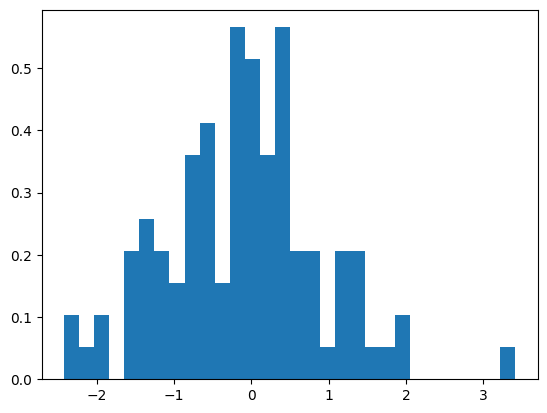

In [22]:
import matplotlib.pyplot as plt

plt.hist(
    lista2,
    bins=30,
    density=True
)

plt.show()

Aproximando la distribución de "lista2" a la distribución normal estándar, **¡¡¡podemos plantearnos preguntas con relación a la "lista"!!!**

Por ejemplo, qué tan probable es que, al elegir un rendimiento diario para la empresa apple, tomado del conjunto "lista", su valor esté entre 0.003 y 0.007.

Solución. Nos están solicitando "medir" la probabilidad de observar el evento $0.003 \leq \bar{X} \leq 0.007$. Este evento es equivalente a $\frac{0.003-\mu}{\sigma/\sqrt{20}} \leq Z\approx \frac{\bar{X}-\mu}{\sigma/\sqrt{20}} \leq \frac{0.007-\mu}{\sigma/\sqrt{20}}$, cuya probabilidad podemos calcularla con la función de densidad normal estándar.

Para continuar, visualicemos $\mu$ y $\sigma$:


In [23]:
mu = np.mean(data.squeeze().values)
mu

np.float64(0.0006811895112550312)

In [24]:
sigma = np.std(data.squeeze().values,ddof=0)
sigma

np.float64(0.020447863370339527)

In [25]:
from numpy.ma import sqrt
from scipy.stats import norm
# Distribución Normal

# media y desvación estándar de lista
mu # Media
sigma # Desviación estándar

# Calcular la probabilidad de Z (variable aproximadamente normal estándar por aplicacion de TLC)
# esté entre z1 y z2 (valores estandarizados de x1=0.003 y x2=0.007)
x1 = 0.003
x2 = 0.007
z1 = (x1-mu)/(sigma/sqrt(20))
z2 = (x2-mu)/(sigma/sqrt(20))
probabilidad = norm.cdf(z2, loc=0, scale=1) - norm.cdf(z1, loc=0, scale=1)
print(f"La probabilidad de que la variable X esté entre {x1} y {x2} es: {probabilidad}")

La probabilidad de que la variable X esté entre 0.003 y 0.007 es: 0.22253786057725766


**Ejercicios sobre el Teorema del Límite Central (TLC)**

**Instrucciones:**
En todos los ejercicios, suponga que las observaciones son independientes y provienen de una población con media y varianza finitas. Utilice el Teorema del Límite Central para responder las preguntas planteadas.

**Nota.** En cada ejercicio, sólo hay que definir las variables $x1$, $x2$, $\mu$ y $\sigma$. Después hay que usa la instrucción

"probabilidad = norm.cdf(z2, loc=0, scale=1) - norm.cdf(z1, loc=0, scale=1)"

**Ejercicio 1. Producción industrial de tornillos**

Una fábrica produce tornillos cuyo peso presenta una media de 8 gramos y una desviación estándar de 1.5 gramos.

Se selecciona una muestra aleatoria de 100 tornillos.

¿Cuál es la probabilidad de que el peso promedio de la muestra sea menor que 7.8 gramos?
¿Cuál es la probabilidad de que el peso promedio de la muestra esté entre 7.9 y 8.2 gramos?

In [32]:
# --- EJERCICIO 1: PRODUCCIÓN INDUSTRIAL DE TORNILLOS (PESOS) ---

# 1. Definir las variables con los datos del problema
mu = 8            # Media poblacional (gramos)
sigma = 1.5       # Desviación estándar poblacional (gramos)
n = 100           # Tamaño de la muestra (tornillos)

# Calcular el error estándar de la media (la desviación para el grupo de 100)
error_estandar = sigma / np.sqrt(n)

print("=== RESPUESTAS EJERCICIO 1: PESO DE TORNILLOS ===")

# --- PREGUNTA 1: Probabilidad de que el promedio sea menor que 7.8 gramos ---
# "Menor que 7.8" significa que viene desde el extremo izquierdo (-infinito) hasta 7.8
x1_a = -np.inf
x2_a = 7.8

# Convertir a valores Z (estandarización)
z1_a = (x1_a - mu) / error_estandar
z2_a = (x2_a - mu) / error_estandar

# Instrucción exacta solicitada por el profesor
probabilidad_a = norm.cdf(z2_a, loc=0, scale=1) - norm.cdf(z1_a, loc=0, scale=1)
print(f"Probabilidad de que sea menor a 7.8g: {probabilidad_a:.4f} o {probabilidad_a * 100:.2f}%")


# --- PREGUNTA 2: Probabilidad entre 7.9 y 8.2 gramos ---
x1_b = 7.9
x2_b = 8.2

# Convertir a valores Z (estandarización)
z1_b = (x1_b - mu) / error_estandar
z2_b = (x2_b - mu) / error_estandar

# Instrucción exacta solicitada por el profesor
probabilidad_b = norm.cdf(z2_b, loc=0, scale=1) - norm.cdf(z1_b, loc=0, scale=1)
print(f"Probabilidad entre 7.9g y 8.2g: {probabilidad_b:.4f} o {probabilidad_b * 100:.2f}%")

=== RESPUESTAS EJERCICIO 1: PESO DE TORNILLOS ===
Probabilidad de que sea menor a 7.8g: 0.0912 o 9.12%
Probabilidad entre 7.9g y 8.2g: 0.6563 o 65.63%


**Ejercicio 2. Gasto diario de consumidores**

Un supermercado ha determinado que el gasto diario por cliente tiene una media de $420 y una desviación estándar de $180.

Durante un día se registra una muestra aleatoria de 64 clientes.

¿Cuál es la probabilidad de que el gasto promedio de la muestra exceda los 450?
¿Cuál es la probabilidad de que el gasto promedio de la muestra sea inferior a $400?

In [33]:
# --- EJERCICIO 2: GASTO DIARIO DE CONSUMIDORES ---

# 1. Definir las variables con los datos del problema
mu = 420          # Media poblacional ($420 pesos)
sigma = 180       # Desviación estándar poblacional ($180 pesos)
n = 64            # Tamaño de la muestra (64 clientes)

# Calcular el error estándar de la media (la desviación para el grupo de 64 clientes)
error_estandar = sigma / np.sqrt(n)

print("=== RESPUESTAS EJERCICIO 2: GASTO DE CONSUMIDORES ===")

# --- PREGUNTA 1: Probabilidad de que el gasto promedio exceda los $450 ---
# "Exceda los 450" significa que va desde 450 (límite inferior) hasta el infinito (límite superior)
x1_a = 450
x2_a = np.inf

# Convertir a valores Z (Estandarización)
z1_a = (x1_a - mu) / error_estandar
z2_a = (x2_a - mu) / error_estandar

# Instrucción exacta solicitada por el profesor
probabilidad_a = norm.cdf(z2_a, loc=0, scale=1) - norm.cdf(z1_a, loc=0, scale=1)
print(f"Probabilidad de que exceda los $450: {probabilidad_a:.4f} o {probabilidad_a * 100:.2f}%")


# --- PREGUNTA 2: Probabilidad de que el gasto promedio sea inferior a $400 ---
# "Inferior a 400" significa que viene desde el extremo izquierdo (-infinito) hasta 400
x1_b = -np.inf
x2_b = 400

# Convertir a valores Z (Estandarización)
z1_b = (x1_b - mu) / error_estandar
z2_b = (x2_b - mu) / error_estandar

# Instrucción exacta solicitada por el profesor
probabilidad_b = norm.cdf(z2_b, loc=0, scale=1) - norm.cdf(z1_b, loc=0, scale=1)
print(f"Probabilidad de que sea inferior a $400: {probabilidad_b:.4f} o {probabilidad_b * 100:.2f}%")

=== RESPUESTAS EJERCICIO 2: GASTO DE CONSUMIDORES ===
Probabilidad de que exceda los $450: 0.0912 o 9.12%
Probabilidad de que sea inferior a $400: 0.1870 o 18.70%


**Ejercicio 3. Tiempo de atención en un centro de soporte técnico**

Una empresa de telecomunicaciones sabe que el tiempo de atención de una llamada tiene una media de 12 minutos y una desviación estándar de 5 minutos.

En un determinado turno se observan 81 llamadas seleccionadas aleatoriamente.

¿Cuál es la probabilidad de que el tiempo promedio de atención sea menor que 11 minutos?
¿Cuál es la probabilidad de que el tiempo promedio se encuentre entre 11.5 y 13 minutos?

In [30]:
# Datos del problema 2
media_pob = 12
desv_pob = 5
n = 81

# Calculamos el error estándar
error_estandar = desv_pob / np.sqrt(n)

# Solución A
prob_A = stats.norm.cdf(11, loc=media_pob, scale=error_estandar)
print(f"Respuesta A (Menor a 11 min): {prob_A:.4f} o {prob_A*100:.2f}%")

# Solución B
prob_13 = stats.norm.cdf(13, loc=media_pob, scale=error_estandar)
prob_11_5 = stats.norm.cdf(11.5, loc=media_pob, scale=error_estandar)
prob_B = prob_13 - prob_11_5
print(f"Respuesta B (Entre 11.5 y 13 min): {prob_B:.4f} o {prob_B*100:.2f}%")

Respuesta A (Menor a 11 min): 0.0359 o 3.59%
Respuesta B (Entre 11.5 y 13 min): 0.7800 o 78.00%


**Ejercicio 4. Rendimiento de una cartera de microcréditos**

Una institución financiera ha estimado que la utilidad anual por crédito otorgado tiene una media de 1,200 pesos y una desviación estándar de 600 pesos.

Se selecciona aleatoriamente una cartera de 225 créditos.

¿Cuál es la probabilidad de que la utilidad promedio de los créditos de la cartera sea superior a 1,260 pesos?
¿Cuál es la probabilidad de que la utilidad promedio se encuentre entre 1,150 y 1,300 pesos?

In [29]:
# Datos del problema 4
media_pob = 1200
desv_pob = 600
n = 225

# Calculamos el error estándar
error_estandar = desv_pob / np.sqrt(n)

# Solución A (Superior a 1260 significa "1 menos el acumulado a la izquierda")
prob_A = 1 - stats.norm.cdf(1260, loc=media_pob, scale=error_estandar)
print(f"Respuesta A (Superior a $1,260): {prob_A:.4f} o {prob_A*100:.2f}%")

# Solución B
prob_1300 = stats.norm.cdf(1300, loc=media_pob, scale=error_estandar)
prob_1150 = stats.norm.cdf(1150, loc=media_pob, scale=error_estandar)
prob_B = prob_1300 - prob_1150
print(f"Respuesta B (Entre $1,150 y $1,300): {prob_B:.4f} o {prob_B*100:.2f}%")

Respuesta A (Superior a $1,260): 0.0668 o 6.68%
Respuesta B (Entre $1,150 y $1,300): 0.8881 o 88.81%
